In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("/content/insurance.csv")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [10]:

df.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


In [11]:
 df['children'].value_counts()

,count
children,
0.0,574
1.0,321
2.0,240
3.0,156
4.0,25
5.0,17


In [12]:
df['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


In [13]:
df['NUmber_of_past_hospitalizations'].value_counts()

,count
NUmber_of_past_hospitalizations,
1.0,957
2.0,227
0.0,150
3.0,2


#Data Cleaning

In [14]:
df.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [15]:
df.shape

(1338, 13)

In [16]:
df.dropna(inplace = True)

In [17]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
Claim_Amount,0
past_consultations,0
num_of_steps,0
Hospital_expenditure,0
NUmber_of_past_hospitalizations,0


In [18]:

df.shape

(1287, 13)

In [18]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

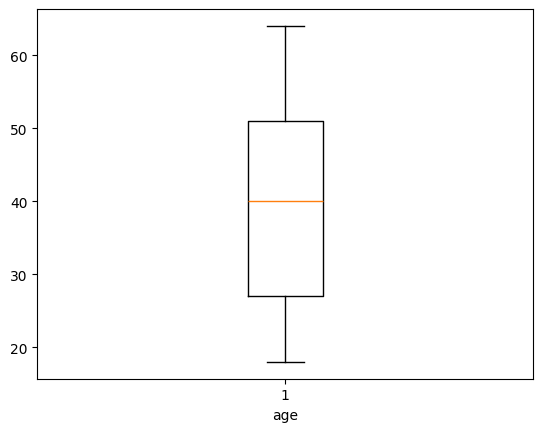

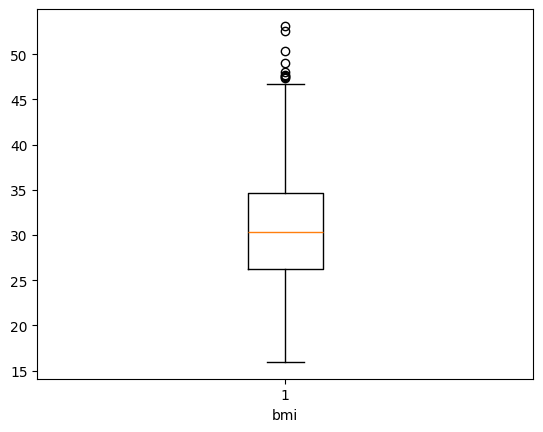

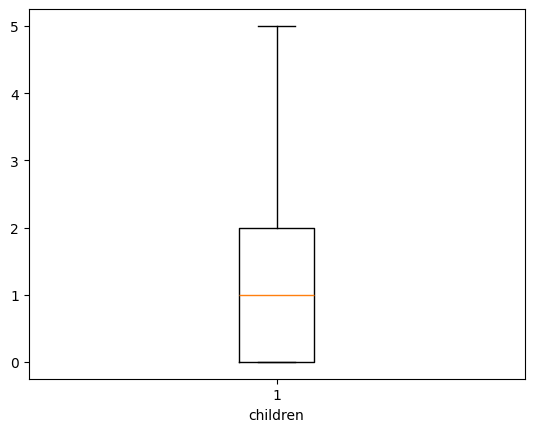

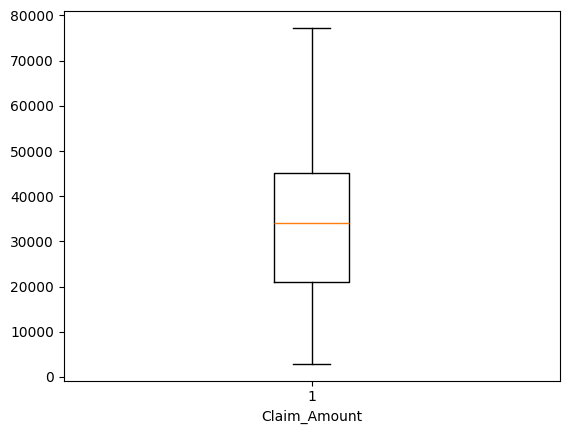

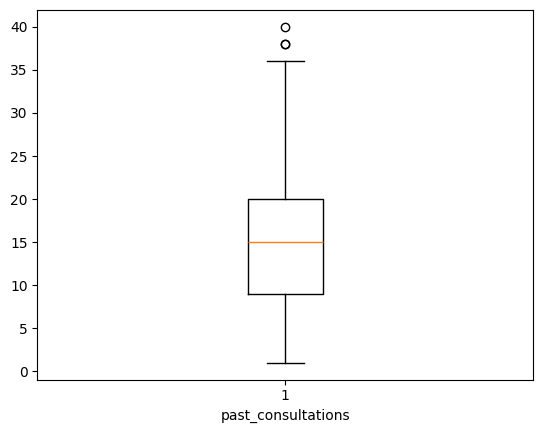

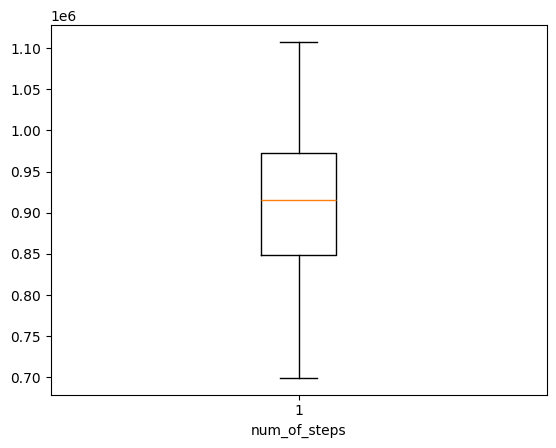

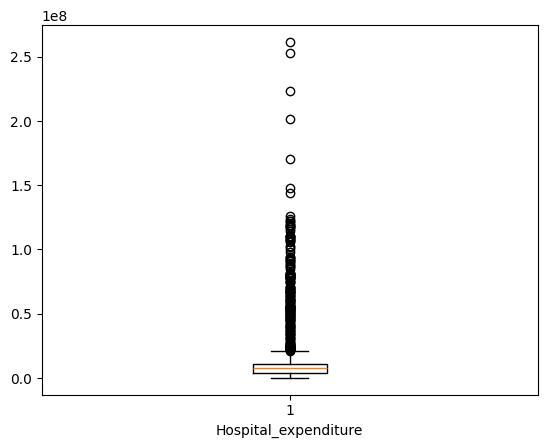

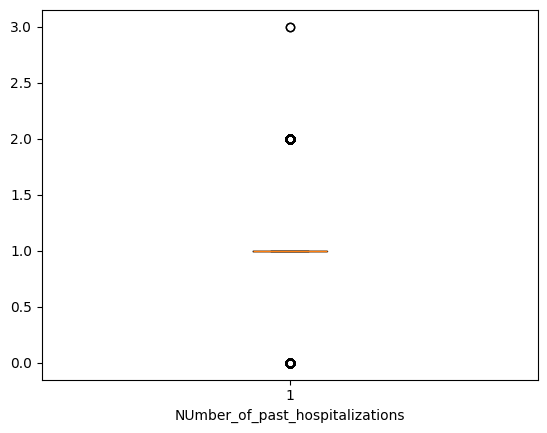

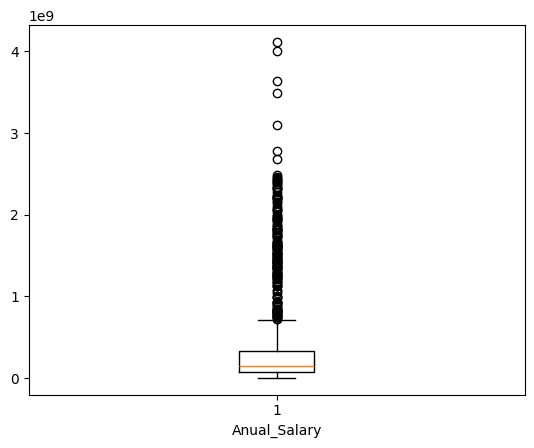

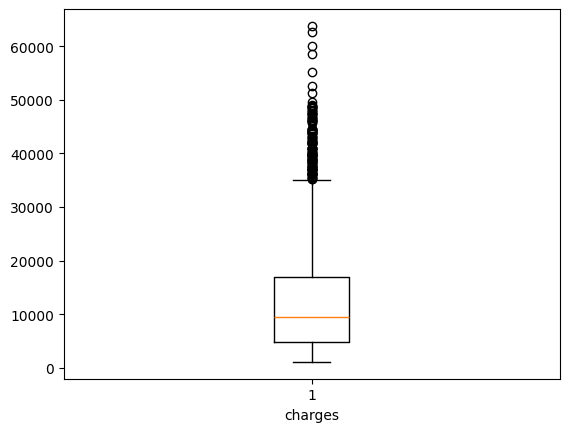

In [21]:
for col in df.columns:
  if df[col].dtype == np.float64:
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.show()


In [19]:
df['sex'].value_counts()

,count
sex,
female,648
male,639


In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


In [28]:
for i in df.columns:
  if df[i].dtype == 'object':
    df[i] = le.fit_transform(df[i])

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1287 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1287 non-null   float64
 1   sex                              1287 non-null   int64  
 2   bmi                              1287 non-null   float64
 3   children                         1287 non-null   float64
 4   smoker                           1287 non-null   int64  
 5   Claim_Amount                     1287 non-null   float64
 6   past_consultations               1287 non-null   float64
 7   num_of_steps                     1287 non-null   float64
 8   Hospital_expenditure             1287 non-null   float64
 9   NUmber_of_past_hospitalizations  1287 non-null   float64
 10  Anual_Salary                     1287 non-null   float64
 11  region                           1287 non-null   int64  
 12  charges                  

In [49]:
X = df.drop(['charges'], axis = 1)
y = df['charges']

In [31]:
X

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,0,35.530,0.0,1,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,1
1334,31.0,0,38.095,1.0,1,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,0
1335,52.0,1,34.485,3.0,1,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,1
1336,45.0,1,30.360,0.0,1,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,2


In [38]:
vif_data = pd.DataFrame()


In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [46]:
vif_data['columns'] = X.columns
vif_data["VIF values"] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns)) ]

In [47]:
print(vif_data)

                            columns  VIF values
0                               age   13.710629
1                               sex    2.009831
2                               bmi   30.159136
3                          children    1.972347
4                            smoker    4.073851
5                      Claim_Amount    6.952488
6                past_consultations    8.593570
7                      num_of_steps   71.160415
8              Hospital_expenditure   30.397183
9   NUmber_of_past_hospitalizations   17.904578
10                     Anual_Salary   48.618196
11                           region    2.933951


In [50]:
 df = df.drop(['num_of_steps'],axis = 1)

In [52]:
X = df.drop(['charges'], axis = 1)
y = df['charges']
vif_data = pd.DataFrame()
vif_data['columns'] = X.columns
vif_data["VIF values"] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns)) ]
print(vif_data)

                            columns  VIF values
0                               age   10.736430
1                               sex    1.984762
2                               bmi   14.403274
3                          children    1.955069
4                            smoker    3.553972
5                      Claim_Amount    6.464483
6                past_consultations    7.933581
7              Hospital_expenditure   30.250111
8   NUmber_of_past_hospitalizations   15.564821
9                      Anual_Salary   46.506789
10                           region    2.924170


In [53]:
df = df.drop(['Hospital_expenditure'], axis = 1)

In [54]:
X = df.drop(['charges'], axis = 1)
y = df['charges']
vif_data = pd.DataFrame()
vif_data['columns'] = X.columns
vif_data["VIF values"] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns)) ]
print(vif_data)

                           columns  VIF values
0                              age   10.729409
1                              sex    1.984641
2                              bmi   13.825189
3                         children    1.949456
4                           smoker    3.219569
5                     Claim_Amount    6.463925
6               past_consultations    7.855977
7  NUmber_of_past_hospitalizations   14.228708
8                     Anual_Salary    4.548385
9                           region    2.917989


In [55]:
df = df.drop(['bmi'], axis = 1)

In [56]:
X = df.drop(['charges'], axis = 1)
y = df['charges']
vif_data = pd.DataFrame()
vif_data['columns'] = X.columns
vif_data["VIF values"] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns)) ]
print(vif_data)

                           columns  VIF values
0                              age    9.506908
1                              sex    1.897528
2                         children    1.943640
3                           smoker    3.147009
4                     Claim_Amount    5.842656
5               past_consultations    7.215070
6  NUmber_of_past_hospitalizations   13.896002
7                     Anual_Salary    4.510770
8                           region    2.593705


In [59]:
df = df.drop(['NUmber_of_past_hospitalizations'], axis = 1)

In [60]:
X = df.drop(['charges'], axis = 1)
y = df['charges']
vif_data = pd.DataFrame()
vif_data['columns'] = X.columns
vif_data["VIF values"] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns)) ]
print(vif_data)

              columns  VIF values
0                 age    6.697141
1                 sex    1.896562
2            children    1.805263
3              smoker    3.028221
4        Claim_Amount    5.593017
5  past_consultations    7.046948
6        Anual_Salary    3.706260
7              region    2.593592


MODEL BUILDING

In [61]:
x = df.drop(['charges'], axis = 1)
y = df['charges']

In [62]:
x

,age,sex,children,smoker,Claim_Amount,past_consultations,Anual_Salary,region
0,18.0,1,0.0,0,29087.54313,17.0,5.578497e+07,2
1,18.0,1,0.0,0,39053.67437,7.0,1.370089e+07,2
2,18.0,1,0.0,0,39023.62759,19.0,7.352311e+07,2
3,18.0,1,0.0,0,28185.39332,11.0,7.581968e+07,2
4,18.0,1,0.0,0,14697.85941,16.0,2.301232e+07,2
...,...,...,...,...,...,...,...,...
1333,33.0,0,0.0,1,63142.25346,32.0,3.101107e+09,1
1334,31.0,0,1.0,1,43419.95227,31.0,3.484216e+09,0
1335,52.0,1,3.0,1,52458.92353,25.0,3.640807e+09,1
1336,45.0,1,0.0,1,69927.51664,34.0,4.006359e+09,2


In [63]:
y

,charges
0,1121.87390
1,1131.50660
2,1135.94070
3,1136.39940
4,1137.01100
...,...
1333,55135.40209
1334,58571.07448
1335,60021.39897
1336,62592.87309


In [67]:
from sklearn.model_selection import train_test_split

In [71]:

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 7)

Training the model

In [74]:
from sklearn.linear_model import LinearRegression

In [75]:
model = LinearRegression()

In [76]:
model.fit(x_train, y_train)

LinearRegression()

In [77]:
y_pred = model.predict(x_test)

Testing the model

In [79]:
y_pred

array([ 4598.79402177, 20783.61033094,  4667.01321337,  9536.08656584,
       12655.06025316, 11472.44009093, 14077.6739905 , 53865.47705314,
        6466.34598646,  5586.23864698,  4426.31679122,  6686.48999193,
        3972.99158972,  3807.01114947, 14310.70866573,  4338.39970055,
        9524.98624412, 19814.6527398 ,  9483.55223776, 10496.05167846,
        2822.00959863,  8008.38978451,  3819.17605424,  7220.67355036,
        8402.93133543, 12688.61227589,  8575.5353743 ,  7424.46901201,
       28560.91909119, 15631.51479211,  8134.77942951, 26159.69970525,
        2656.16386795, 10574.28723555,  5992.86425794,  3894.15022185,
       13305.32305391, 12255.10255404, 23488.92321048, 13185.72010536,
        5373.88909729,  8877.13293434,  9828.48124279,  7796.55615654,
        5033.18929933, 11332.33512992,  6598.55466201,  6277.77497815,
        7010.51034028, 40982.56945648,  4924.4305079 , 11689.10322347,
       12724.97516248,  6092.6928153 , 11279.70693818, 12213.57014933,
      

In [80]:
from sklearn.metrics import r2_score, mean_squared_error

In [83]:
print (r2_score(y_test, y_pred))

0.9400827748877334
